# Sistema de análisis de bienestar digital estudiantil

## Introducción

En el contexto educativo, el bienestar emocional de los estudiantes se ha convertido en una prioridad para las instituciones. Sin embargo, cuando existen muchos factores asociados, como el uso de redes sociales, las horas de sueño, el estrés, la actividad física, la interacción social y el rendimiento académico, puede ser difícil identificar qué estudiantes o perfiles requieren mayor atención preventiva.

Este proyecto busca apoyar a la Coordinación de Bienestar Estudiantil en la toma de decisiones mediante un sistema analítico que permita transformar datos en información accionable. El objetivo de negocio es identificar perfiles de estudiantes con mayor riesgo de ansiedad alta, para que el área de bienestar pueda priorizar campañas, estrategias de acompañamiento y acciones preventivas de manera más informada.

Para lograrlo, este notebook desarrolla la capa de Machine Learning del proyecto integrador. A partir del dataset seleccionado, se realizará un análisis exploratorio de datos, una segmentación de estudiantes mediante clustering, un modelo supervisado para predecir riesgo alto de ansiedad y un análisis de tendencias por edad. Además, se generarán resultados analíticos, como segmentos, predicciones y scores de riesgo, que posteriormente serán organizados en un almacén de datos y consultados mediante un asistente RAG.

La finalidad del sistema no es realizar diagnósticos clínicos, sino ofrecer una herramienta de apoyo para que un usuario no técnico pueda comprender los principales hallazgos y tomar mejores decisiones preventivas dentro del área de bienestar estudiantil.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# 1. CARGA DE LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import os
from datetime import datetime

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE


# Modelo supervisado
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Configuración general
pd.set_option('display.max_columns', None)

In [ ]:
# ============================================================
# 2. CARGA DEL DATASET
# ============================================================

#file_id = "1xboyYF6319hCe_sJWpqfG4O_Ga8FK8HY"
#url = f"https://drive.google.com/uc?id={file_id}"


df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

# Crear un identificador único para cada registro solo si no existe
if 'student_id' not in df.columns:
    df.insert(0, 'student_id', range(1, len(df) + 1))

# Mostrar primeras filas
df.head()

,student_id,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,1,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,2,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,3,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,4,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,5,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [ ]:
# ============================================================
# 3. REVISIÓN INICIAL DEL DATASET
# ============================================================

print("----------------------- Tamaño del dataset -----------------------")
print(df.shape)

print("\n-----------------------Columnas -----------------------")
print(df.columns.tolist())

print("\n----------------------- Tipos de datos -----------------------")
print(df.dtypes)

print("\n----------------------- Primeras filas -----------------------")
display(df.head())


----------------------- Tamaño del dataset -----------------------
(1200, 14)

-----------------------Columnas -----------------------
['student_id', 'age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']

----------------------- Tipos de datos -----------------------
student_id                    int64
age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

----------------

,student_id,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,1,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,2,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,3,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,4,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,5,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [ ]:
# Revisar valores faltantes
missing_values = df.isnull().sum()

print("Valores faltantes por columna:")
print(missing_values)

Valores faltantes por columna:
student_id                  0
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


In [ ]:
# Revisar duplicados
duplicados = df.duplicated().sum()

print(f"Registros duplicados: {duplicados}")

Registros duplicados: 0


In [ ]:
# Estadísticas descriptivas
df.describe()

,student_id,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,600.500000,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,346.554469,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,1.000000,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,300.750000,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,600.500000,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,900.250000,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,1200.000000,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [ ]:
# Estadísticas de variables categóricas
df.describe(include='object')

,gender,platform_usage,social_interaction_level
count,1200,1200,1200
unique,2,3,3
top,male,Instagram,medium
freq,615,411,416


In [ ]:
# ============================================================
# 4. CREACIÓN DE VARIABLE OBJETIVO
# ============================================================

# Se crea una variable binaria:
# 1 = riesgo alto de ansiedad
# 0 = riesgo no alto de ansiedad

df['high_anxiety_risk'] = np.where(df['anxiety_level'] >= 7, 1, 0)

print("Distribución de high_anxiety_risk:")
print(df['high_anxiety_risk'].value_counts())

print("\nDistribución porcentual:")
print(round(df['high_anxiety_risk'].value_counts(normalize=True) * 100, 2))

Distribución de high_anxiety_risk:
high_anxiety_risk
0    706
1    494
Name: count, dtype: int64

Distribución porcentual:
high_anxiety_risk
0    58.83
1    41.17
Name: proportion, dtype: float64


## Justificación de la variable objetivo

Se creó la variable `high_anxiety_risk` a partir de la columna `anxiety_level`.

Los registros con `anxiety_level >= 7` fueron clasificados como casos de riesgo alto de ansiedad. Esta transformación permite convertir una medición numérica en una categoría útil para la toma de decisiones.

El objetivo no es realizar un diagnóstico clínico, sino identificar perfiles que podrían requerir mayor atención preventiva desde el área de bienestar estudiantil.

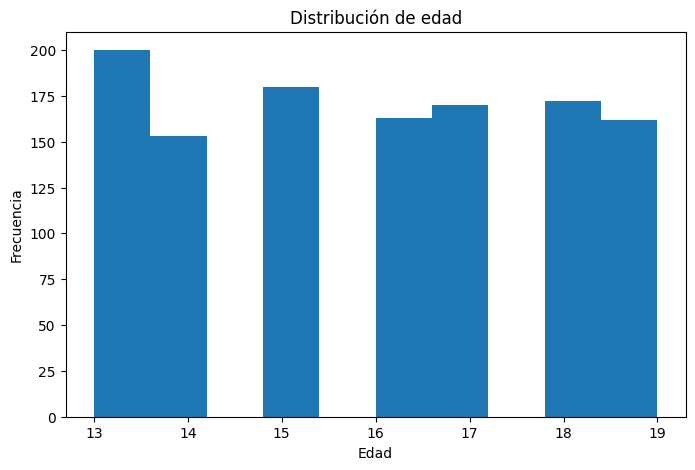

In [ ]:
# ============================================================
# 5. ANÁLISIS EXPLORATORIO DE DATOS
# ============================================================

# Distribución de edad
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=10)
plt.title("Distribución de edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

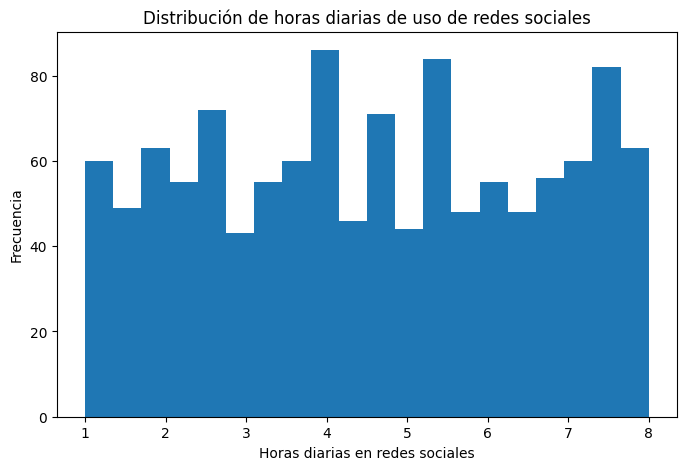

In [ ]:
# Distribución de horas diarias en redes sociales
plt.figure(figsize=(8, 5))
plt.hist(df['daily_social_media_hours'], bins=20)
plt.title("Distribución de horas diarias de uso de redes sociales")
plt.xlabel("Horas diarias en redes sociales")
plt.ylabel("Frecuencia")
plt.show()

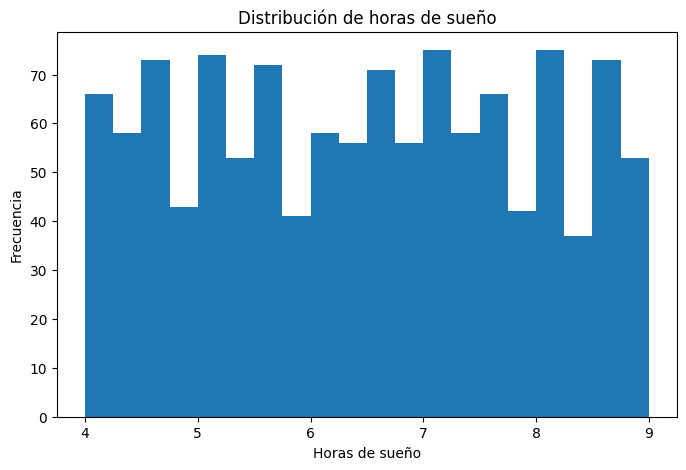

In [ ]:
# Distribución de horas de sueño
plt.figure(figsize=(8, 5))
plt.hist(df['sleep_hours'], bins=20)
plt.title("Distribución de horas de sueño")
plt.xlabel("Horas de sueño")
plt.ylabel("Frecuencia")
plt.show()

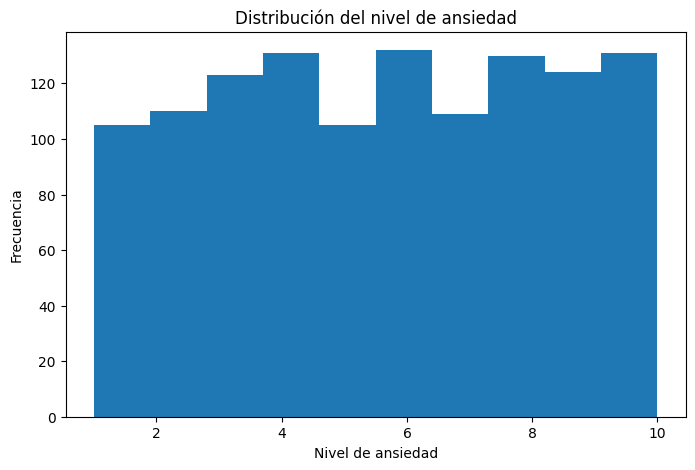

In [ ]:
# Distribución del nivel de ansiedad
plt.figure(figsize=(8, 5))
plt.hist(df['anxiety_level'], bins=10)
plt.title("Distribución del nivel de ansiedad")
plt.xlabel("Nivel de ansiedad")
plt.ylabel("Frecuencia")
plt.show()

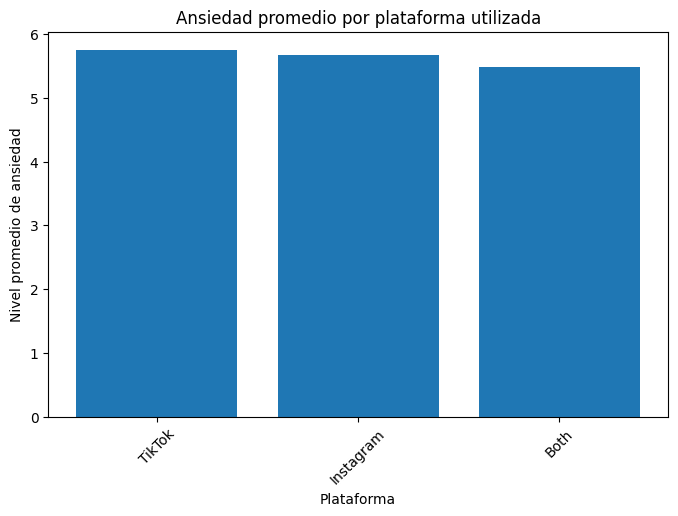

,anxiety_level
platform_usage,
TikTok,5.748744
Instagram,5.669100
Both,5.488491


In [ ]:
# Promedio de ansiedad por plataforma
platform_anxiety = df.groupby('platform_usage')['anxiety_level'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(platform_anxiety.index, platform_anxiety.values)
plt.title("Ansiedad promedio por plataforma utilizada")
plt.xlabel("Plataforma")
plt.ylabel("Nivel promedio de ansiedad")
plt.xticks(rotation=45)
plt.show()

platform_anxiety

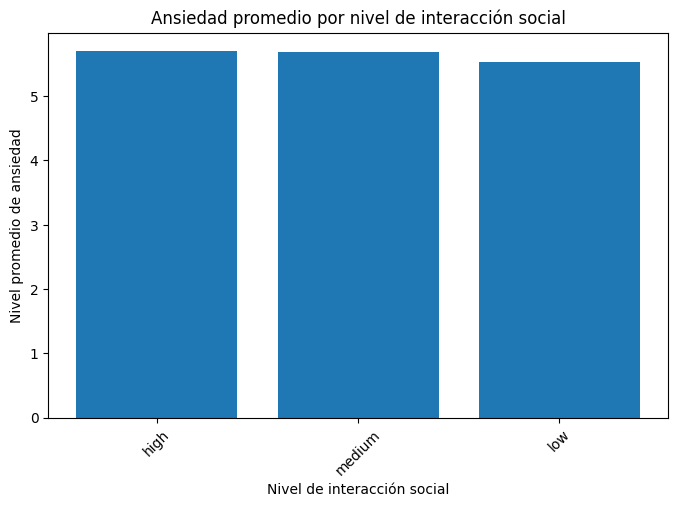

,anxiety_level
social_interaction_level,
high,5.704607
medium,5.687500
low,5.525301


In [ ]:
# Promedio de ansiedad por nivel de interacción social
interaction_anxiety = df.groupby('social_interaction_level')['anxiety_level'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(interaction_anxiety.index, interaction_anxiety.values)
plt.title("Ansiedad promedio por nivel de interacción social")
plt.xlabel("Nivel de interacción social")
plt.ylabel("Nivel promedio de ansiedad")
plt.xticks(rotation=45)
plt.show()

interaction_anxiety

In [ ]:
# Comparación entre riesgo alto y no alto de ansiedad
risk_summary = df.groupby('high_anxiety_risk')[
    [
        'daily_social_media_hours',
        'sleep_hours',
        'screen_time_before_sleep',
        'academic_performance',
        'physical_activity',
        'stress_level',
        'addiction_level'
    ]
].mean().round(2)

risk_summary

,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,addiction_level
high_anxiety_risk,,,,,,,
0,4.46,6.43,1.74,3.03,1.03,5.45,5.54
1,4.65,6.47,1.74,2.94,0.99,5.44,5.61


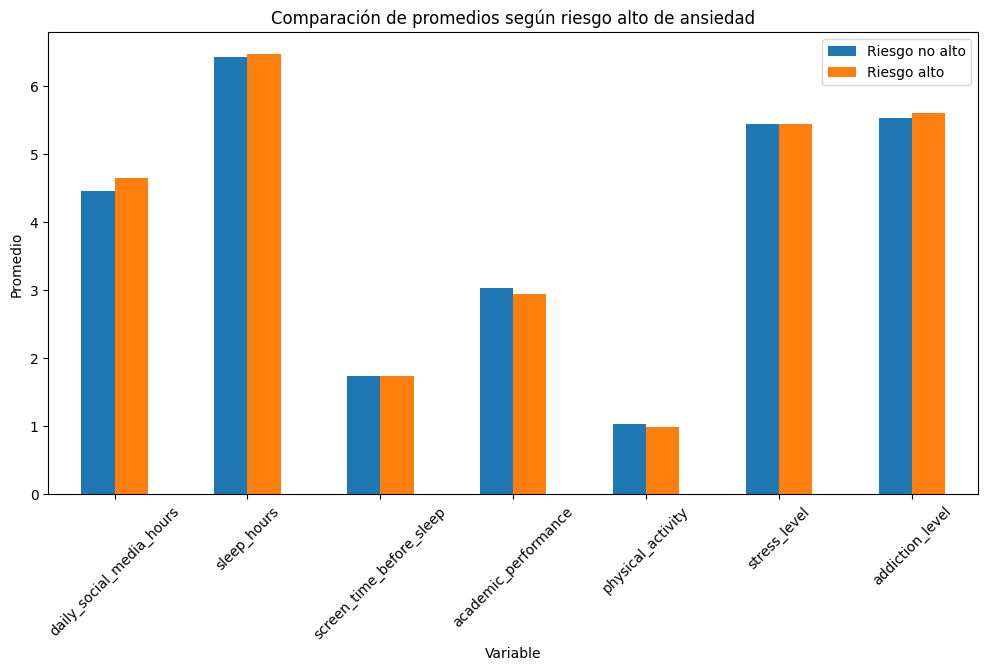

In [ ]:
# Gráfica comparativa de variables promedio por riesgo
risk_summary.T.plot(kind='bar', figsize=(12, 6))
plt.title("Comparación de promedios según riesgo alto de ansiedad")
plt.xlabel("Variable")
plt.ylabel("Promedio")
plt.xticks(rotation=45)
plt.legend(["Riesgo no alto", "Riesgo alto"])
plt.show()

In [ ]:
# ============================================================
# 7. CLUSTERING
# ============================================================

# Variables seleccionadas para segmentar perfiles de bienestar digital

cluster_features = [
    'daily_social_media_hours',
    'sleep_hours',
    'screen_time_before_sleep',
    'academic_performance',
    'physical_activity',
    'stress_level',
    'anxiety_level',
    'addiction_level'
]

X_cluster = df[cluster_features].copy()

# Escalar variables numéricas
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

In [ ]:
#Modelo K-MEANS

k_values = []
inertia = []
silhouette_scores = []

K = range(2, 8)

for k in K:

    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)

    k_values.append(k)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_cluster_scaled, labels)
    )


results_df = pd.DataFrame({
    'k': k_values,
    'inertia': inertia,
    'silhouette_score': silhouette_scores
})


results_df['inertia'] = results_df['inertia'].round(2)
results_df['silhouette_score'] = results_df['silhouette_score'].round(4)

# Mostrar tabla
print(results_df)

   k  inertia  silhouette_score
0  2  8677.87            0.0951
1  3  8062.18            0.0894
2  4  7579.75            0.0922
3  5  7186.89            0.0927
4  6  6864.22            0.0951
5  7  6558.93            0.0990


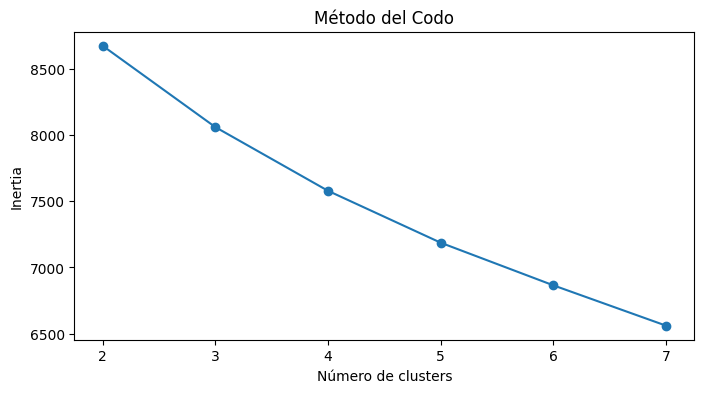

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(K, inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inertia')
plt.title('Método del Codo')
plt.show()

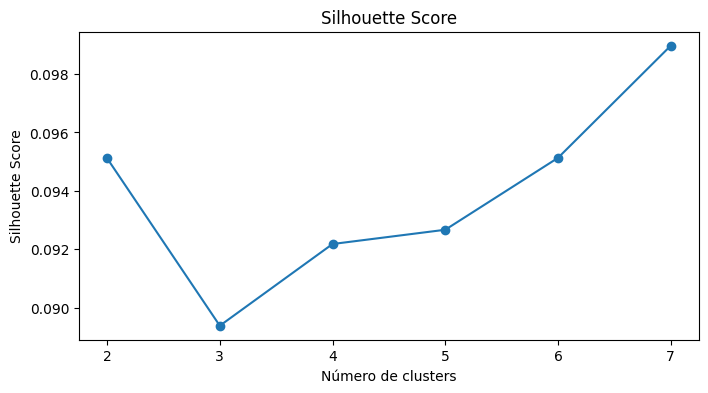

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=7,random_state=42,n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)

In [ ]:
df.head()

,student_id,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,high_anxiety_risk,segment_id,segment_name,priority_level,high_anxiety_risk_predicted,risk_score,risk_score_level,dbscan_segment_id,cluster
0,1,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0,0,0,Bajo riesgo,Baja,0,0.465850,Medio,-1,0
1,2,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0,0,1,Riesgo medio,Media,1,0.527021,Medio,-1,1
2,3,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,0,2,Riesgo alto,Alta,0,0.395526,Bajo,-1,2
3,4,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0,1,6,Riesgo significativo,Alta,0,0.454094,Medio,-1,6
4,5,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0,0,5,Riesgo intermedio,Media,0,0.484134,Medio,-1,5
